# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Cargar datos

# Carga de la bbdd Banco

In [2]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260504.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para perfil de cliente
cols = ["age", "job", "marital", "education", "balance", "default", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  string
 2   marital    11162 non-null  string
 3   education  11162 non-null  string
 4   balance    11162 non-null  int64 
 5   default    11162 non-null  string
 6   housing    11162 non-null  string
 7   loan       11162 non-null  string
 8   deposit    11162 non-null  string
dtypes: int64(2), string(7)
memory usage: 1.1 MB


In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 34, 44, 54, 64, 120], labels=["Menor 34", "35-44", "45-54", "55-64", "65 o más"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

In [5]:
dist_edad_banco = df_perfil.groupby("age_group").size()
dist_edad_banco

age_group
Menor 34    3908
35-44       3369
45-54       2204
55-64       1256
65 o más     425
dtype: int64

# Carga de csv proyecciones poblacionales

In [6]:
proyeccion = pd.read_csv("../../data/df_original_proyeccion_INE_2026-2036_260511.csv")
pd.options.display.float_format = '{:,.2f}'.format
proyeccion.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   Menor 34          11 non-null     float64
 2   35-44             11 non-null     float64
 3   45-54             11 non-null     float64
 4   55-64             11 non-null     float64
 5   65 o más          11 non-null     float64
 6   Total_pobl        11 non-null     float64
 7   Crecimiento_pobl  11 non-null     str    
 8   Edad_media        11 non-null     str    
 9   Ind_envejecer     11 non-null     str    
 10  Saldo_vegetativo  11 non-null     str    
 11  Saldo_migratorio  11 non-null     str    
 12  Tasa_mortalidad   11 non-null     str    
 13  Tasa_natalidad    11 non-null     str    
dtypes: float64(6), int64(1), str(7)
memory usage: 2.0 KB


In [7]:
# Identificar columnas que son string
cols_str = proyeccion.select_dtypes(include="object").columns

# Reemplazar comas y convertir a float en todas ellas
for col in cols_str:
    proyeccion[col] = (
        proyeccion[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

proyeccion.dtypes

C:\Users\misab\AppData\Local\Temp\ipykernel_25832\1066721387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_str = proyeccion.select_dtypes(include="object").columns


Periodo               int64
Menor 34            float64
35-44               float64
45-54               float64
55-64               float64
65 o más            float64
Total_pobl          float64
Crecimiento_pobl    float64
Edad_media          float64
Ind_envejecer       float64
Saldo_vegetativo    float64
Saldo_migratorio    float64
Tasa_mortalidad     float64
Tasa_natalidad      float64
dtype: object

## 2.Visualizaciones

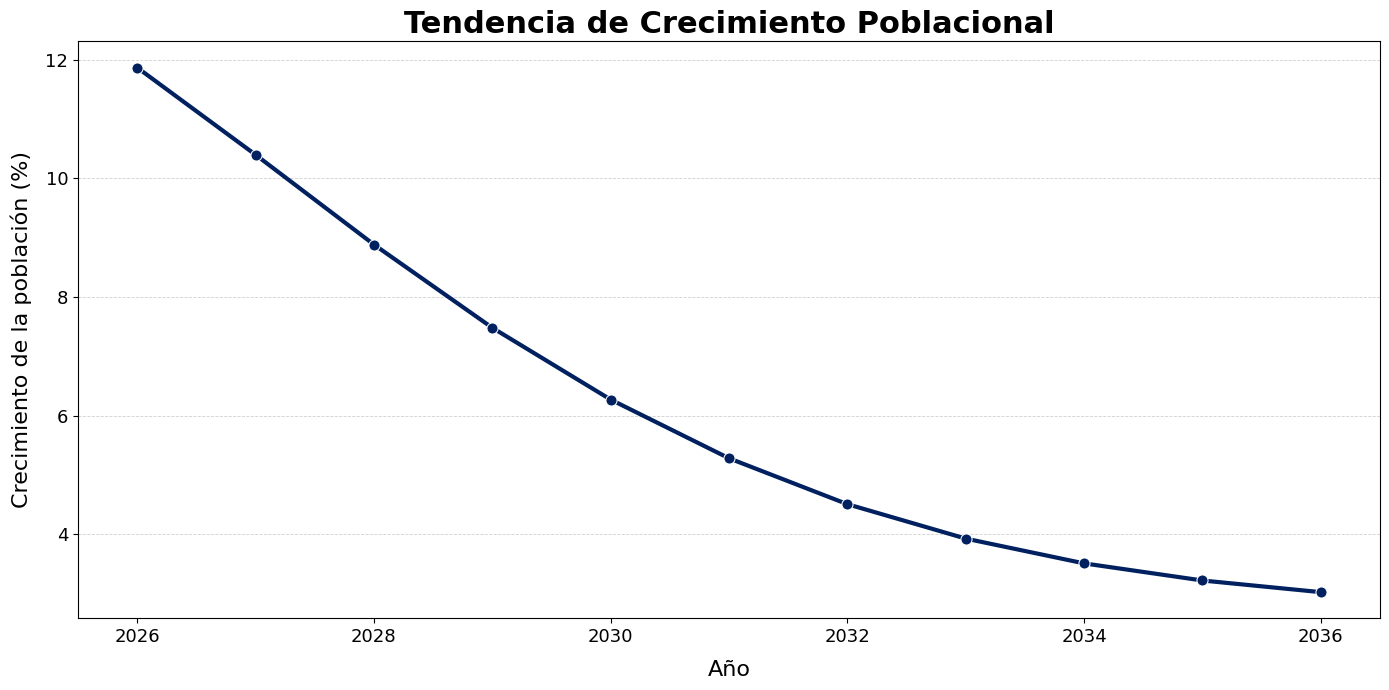

In [8]:
#grafico tendencia crecimiento

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Crecimiento_pobl",
    color="#002060",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia de Crecimiento Poblacional",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Crecimiento de la población (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

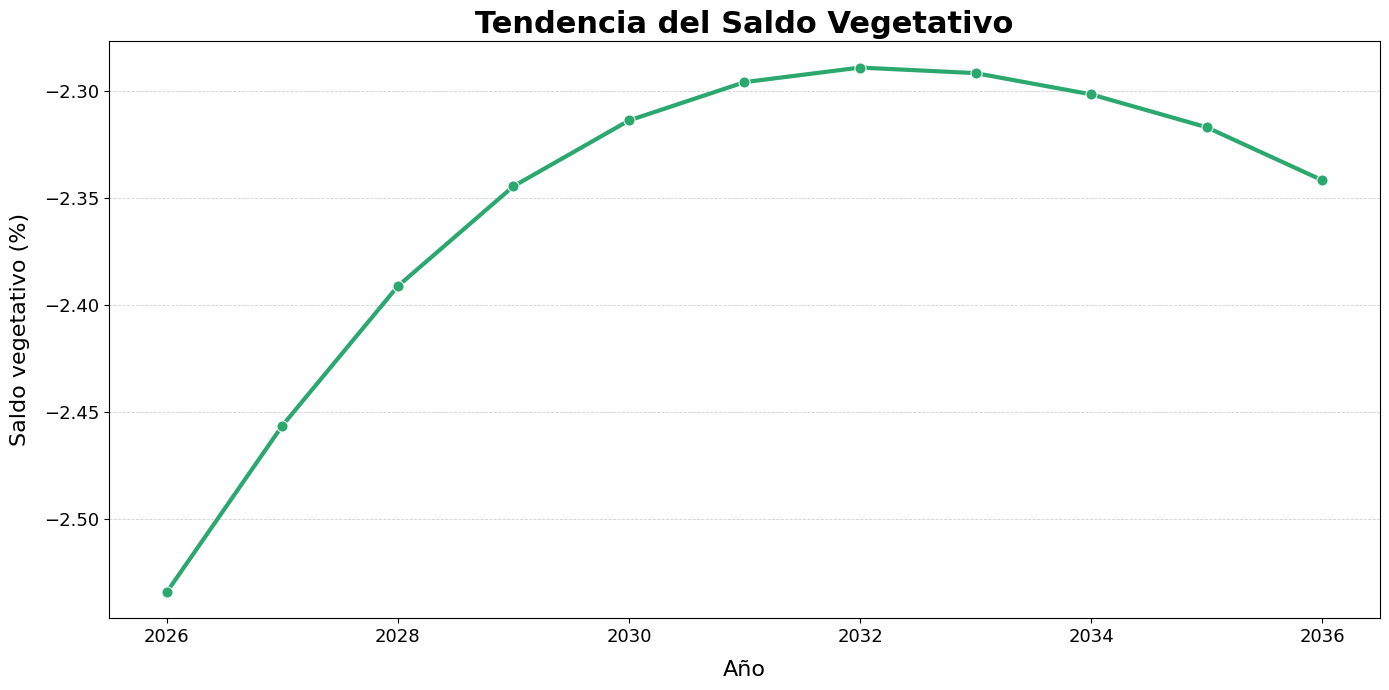

In [9]:
#grafico saldo vegetativo

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_vegetativo",
    color="#2BA86E",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia del Saldo Vegetativo",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Saldo vegetativo (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

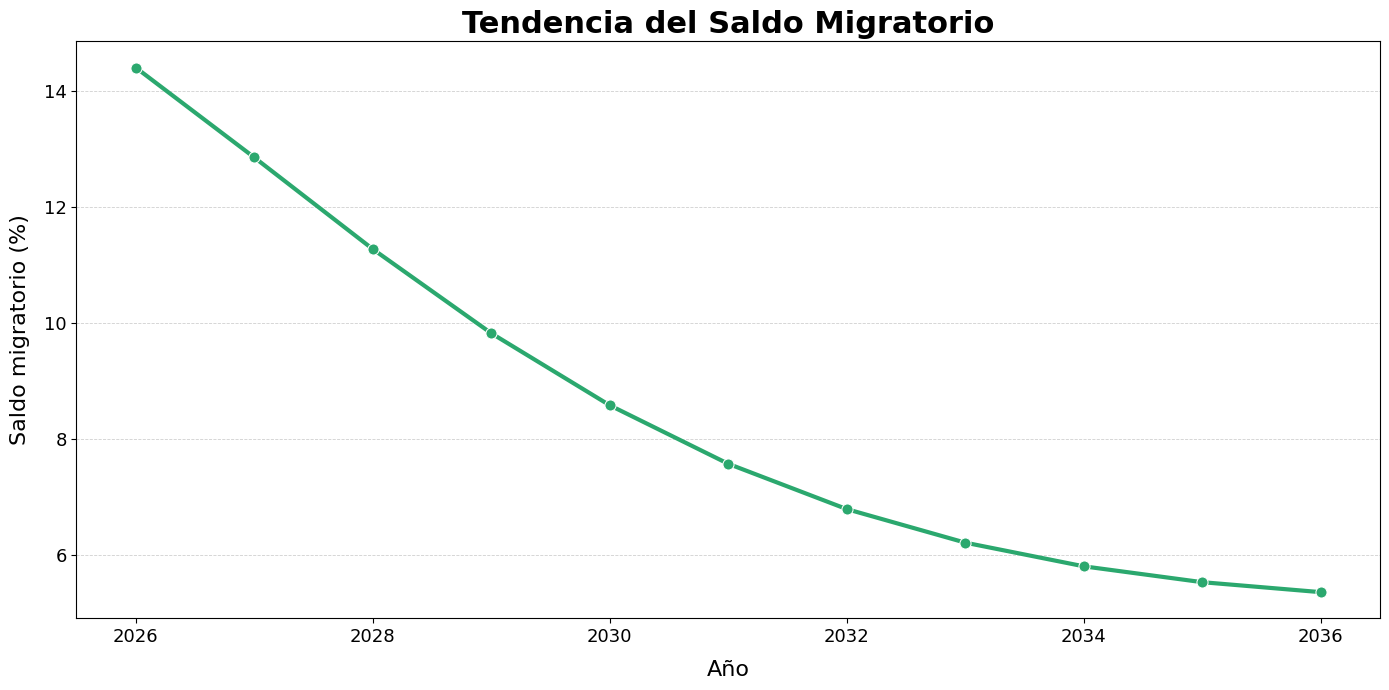

In [10]:
#grafico saldo migratorio

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_migratorio",
    color="#2BA86E",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia del Saldo Migratorio",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Saldo migratorio (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

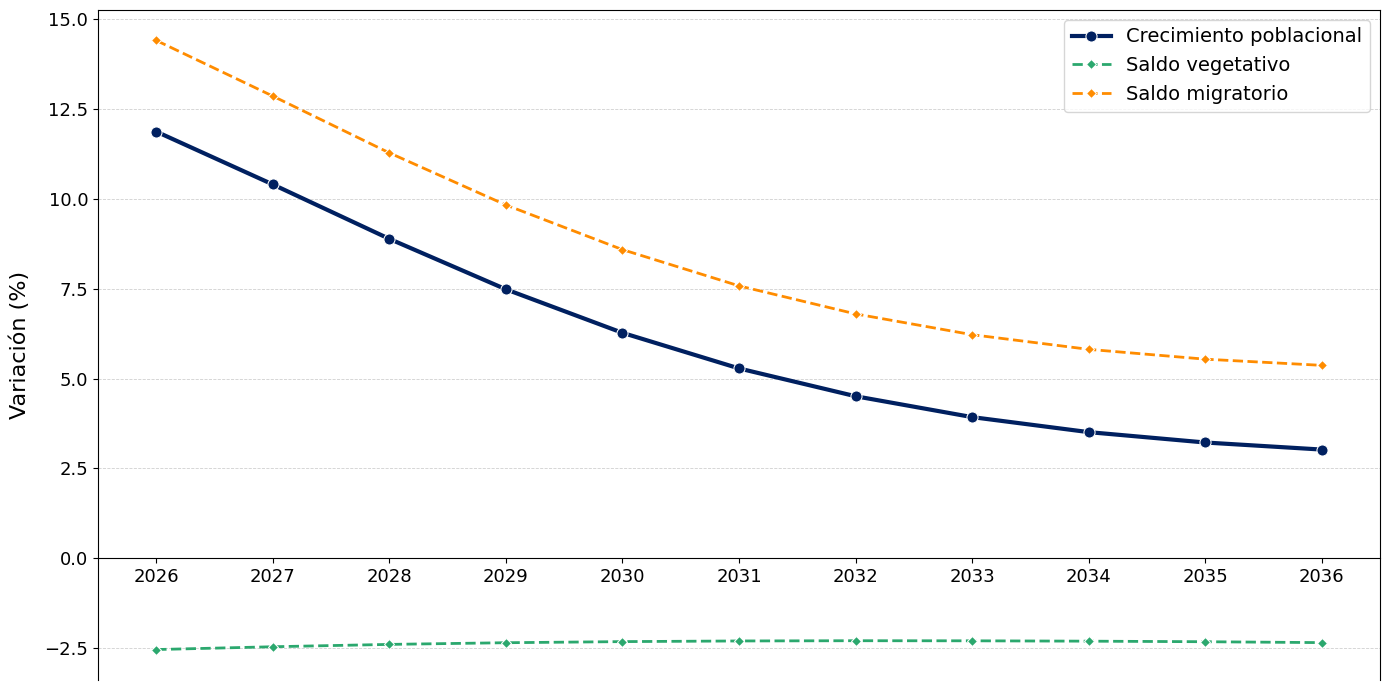

In [11]:
#Grafico tres tendencias en una
plt.figure(figsize=(14, 7))

# Línea 1: Crecimiento poblacional
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Crecimiento_pobl",
    color="#002060",
    linewidth=3,
    marker="o",
    markersize=8,
    label="Crecimiento poblacional"
)

# Línea 2: Saldo vegetativo
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_vegetativo",
    color="#2BA86E",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo vegetativo"
)

# Línea 3: Saldo migratorio
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_migratorio",
    color="#FF8C00",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo migratorio"
)

# Títulos y ejes
#plt.title("Tendencias Demográficas",fontsize=22,fontweight="bold",pad=10)
ax = plt.gca()

# Mover eje X a Y=0
ax.spines['bottom'].set_position(('data', 0))
#ax.spines['top'].set_color('none')
ax.set_xticks(range(2026, 2037))

# Asegurar que los ticks del eje X se vean
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', labelbottom=True)


plt.xlabel(None, fontsize=16, labelpad=10)
plt.ylabel("Variación (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# Leyenda
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()


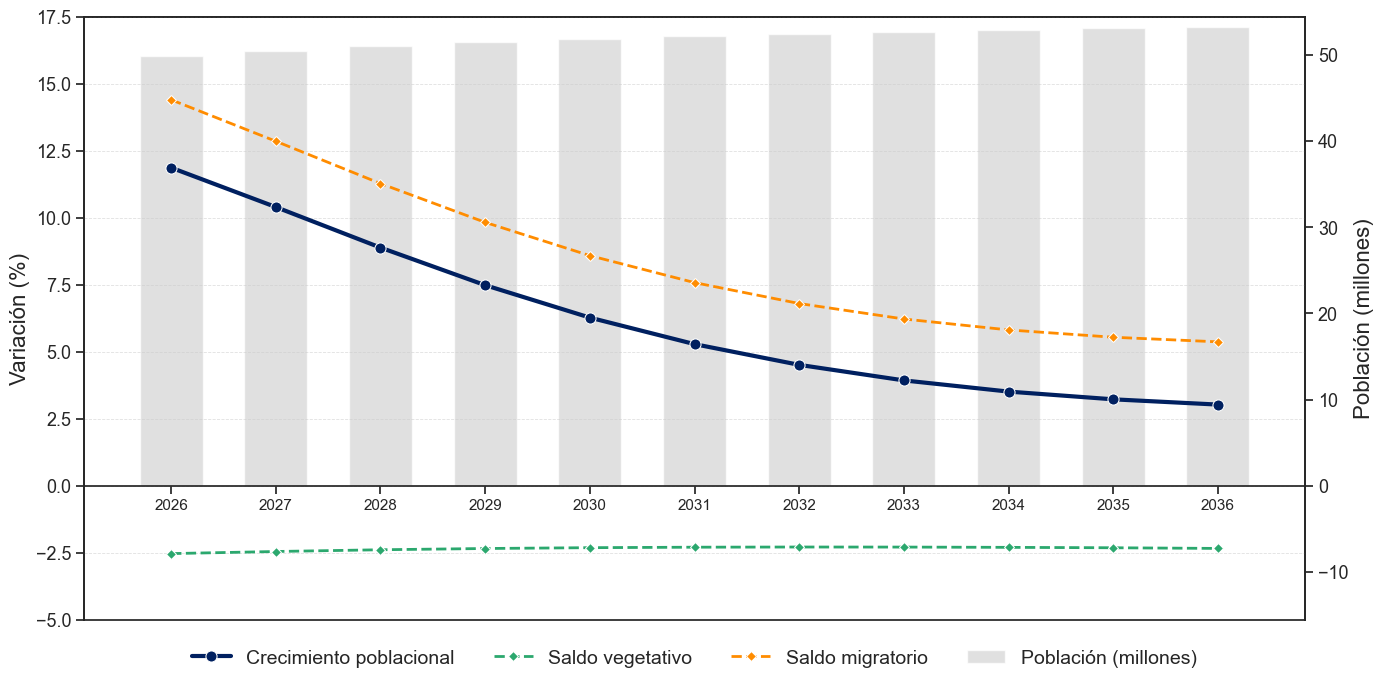

In [ ]:
#opcion 2
plt.figure(figsize=(14, 7))

# --- EJE PRINCIPAL (LÍNEAS) ---
ax = plt.gca()

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Crecimiento_pobl",
    color="#002060",
    linewidth=3,
    marker="o",
    markersize=8,
    label="Crecimiento poblacional",
    ax=ax
)

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_vegetativo",
    color="#2BA86E",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo vegetativo",
    ax=ax
)

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_migratorio",
    color="#FF8C00",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo migratorio",
    ax=ax
)

# --- FIJAMOS RANGO DEL EJE PRINCIPAL (Y1) ---
ax.set_ylim(-5, 17.5)   # NEGATIVOS + más espacio arriba
y1_min, y1_max = ax.get_ylim()

# --- SEGUNDO EJE Y (BARRAS) ---
ax2 = ax.twinx()

pobl_millones = proyeccion["Total_pobl"] / 1_000_000

# --- RANGO FIJO DEL EJE DE POBLACIÓN ---
y2_min_target = 0
y2_max_target = 70
span2 = y2_max_target - y2_min_target

# --- ALINEAR EL 0 DE AMBOS EJES ---
# Posición relativa del 0 en Y1
r = (0 - y1_min) / (y1_max - y1_min)

# Para que el 0 de Y2 esté en la misma altura:
# 0 = y2_min + r * span2  →  y2_min = -r * span2
y2_min = -r * span2
y2_max = y2_min + span2

ax2.set_ylim(y2_min, y2_max)

# --- BARRAS DESDE EL 0 (QUE AHORA ESTÁ ALINEADO) ---
bars = ax2.bar(
    proyeccion["Periodo"],
    pobl_millones,
    bottom=0,
    color="lightgray",
    alpha=0.7,
    width=0.6,
    label="Población (millones)",
    zorder=1
)

# --- LÍNEAS POR DELANTE ---
for line in ax.lines:
    line.set_zorder(3)

ax.set_zorder(2)
ax.patch.set_visible(False)

# --- CONFIGURACIÓN DE EJES ---
ax.spines['bottom'].set_position(('data', 0))
ax.set_xticks(range(2026, 2037))
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', labelbottom=True)

ax.set_xlabel(None, fontsize=16)
ax.set_ylabel("Variación (%)", fontsize=16)

ax2.set_ylabel("Población (millones)", fontsize=16)
ax2.ticklabel_format(style='plain', axis='y')
ax2.tick_params(axis='y', labelsize=13)
for label in ax2.get_yticklabels():
    label.set_fontsize(13)

plt.xticks(fontsize=13)

ax.tick_params(axis='y', labelsize=13)   # solo eje Y1


ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# --- ELIMINAR LEYENDAS AUTOMÁTICAS ---
if ax.legend_ is not None:
    ax.legend_.remove()
if ax2.legend_ is not None:
    ax2.legend_.remove()

# --- LEYENDA ÚNICA ABAJO ---
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    fontsize=14,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()



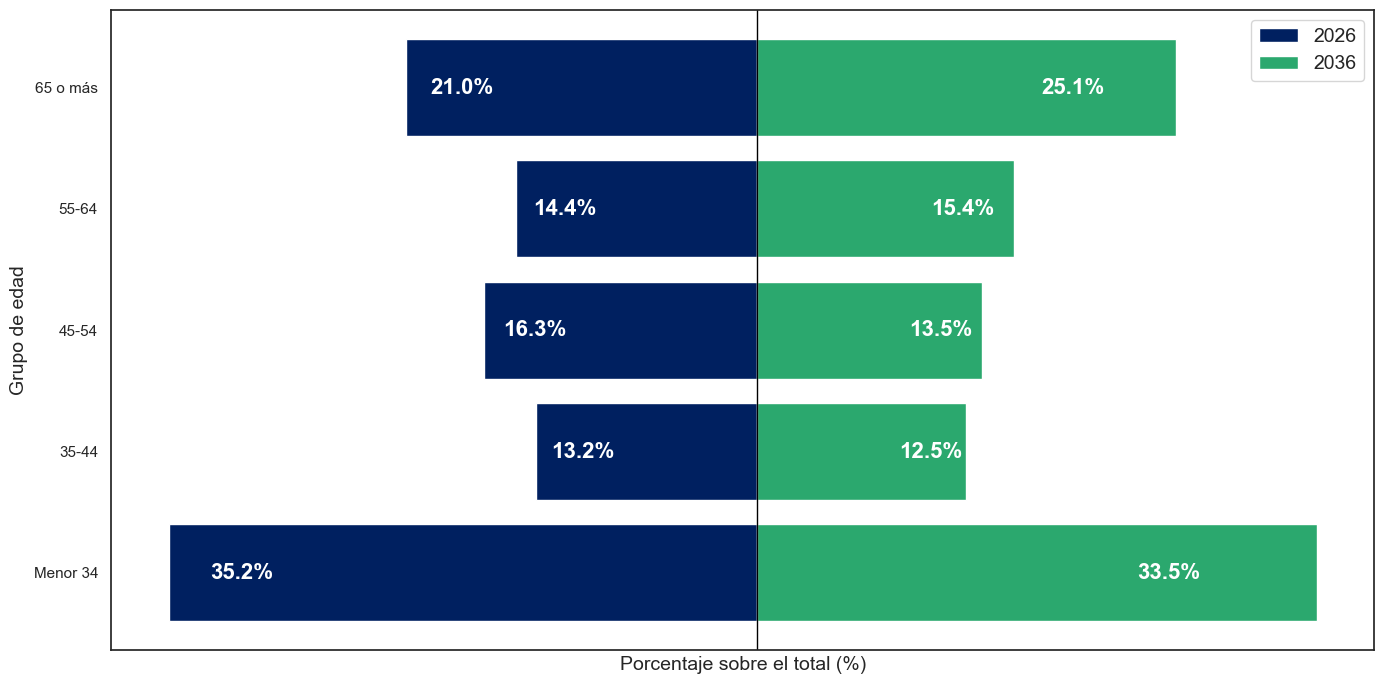

In [13]:
#Gráfico piramide 2026 vs 2036
# 1. Datos

cols_edad = ["Menor 34", "35-44", "45-54", "55-64", "65 o más"]

df_pyr = proyeccion[proyeccion["Periodo"].isin([2026, 2036])].copy()

# Calcular porcentajes
for col in cols_edad:
    df_pyr[col] = df_pyr[col] / df_pyr["Total_pobl"] * 100

# Extraer series
datos_2026 = df_pyr[df_pyr["Periodo"] == 2026][cols_edad].iloc[0].values
datos_2036 = df_pyr[df_pyr["Periodo"] == 2036][cols_edad].iloc[0].values

# Para tornado: 2026 negativo
datos_2026_neg = -datos_2026

ages = cols_edad

# 2. Gráfico tornado

sns.set_theme(style="white")

plt.figure(figsize=(14, 7))

color_2026 = "#002060"
color_2036 = "#2BA86E"

# Barras
plt.barh(ages, datos_2026_neg, color=color_2026, label="2026")
plt.barh(ages, datos_2036, color=color_2036, label="2036")


# 3. Etiquetas dentro de las barras

# 2026 (lado izquierdo)
for y, v in enumerate(datos_2026_neg):
    plt.text(
        v * 0.93, y, f"{abs(v):.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )

# 2036 (lado derecho)
for y, v in enumerate(datos_2036):
    plt.text(
        v *0.68, y, f"{v:.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )


# 4. Estética

plt.axvline(0, color="black", linewidth=1)
#plt.title("Comparación poblacional por grupos de edad: 2026 vs 2036",fontsize=22, fontweight="bold", pad = 10)
plt.xticks([])

plt.xlabel("Porcentaje sobre el total (%)", fontsize=14)
plt.ylabel("Grupo de edad", fontsize=14)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

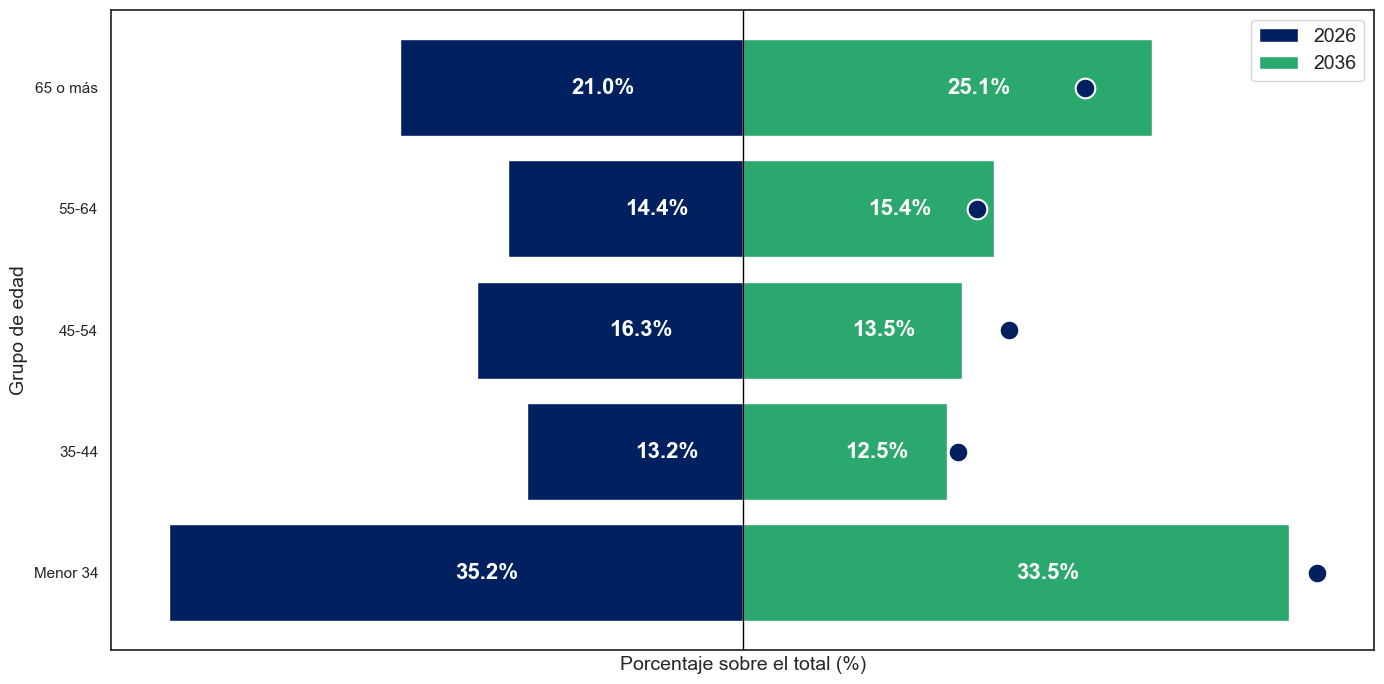

In [42]:
#opcion 2
#Gráfico piramide 2026 vs 2036
# 1. Datos

cols_edad = ["Menor 34", "35-44", "45-54", "55-64", "65 o más"]

df_pyr = proyeccion[proyeccion["Periodo"].isin([2026, 2036])].copy()

# Calcular porcentajes
for col in cols_edad:
    df_pyr[col] = df_pyr[col] / df_pyr["Total_pobl"] * 100

# Extraer series
datos_2026 = df_pyr[df_pyr["Periodo"] == 2026][cols_edad].iloc[0].values
datos_2036 = df_pyr[df_pyr["Periodo"] == 2036][cols_edad].iloc[0].values

# Para tornado: 2026 negativo
datos_2026_neg = -datos_2026

ages = cols_edad

# 2. Gráfico tornado

sns.set_theme(style="white")

plt.figure(figsize=(14, 7))

color_2026 = "#002060"
color_2036 = "#2BA86E"

# Barras
plt.barh(ages, datos_2026_neg, color=color_2026, label="2026")
plt.barh(ages, datos_2036, color=color_2036, label="2036")

# --- NUEVO: puntos de referencia del 2026 en el lado derecho ---
plt.scatter(datos_2026, range(len(ages)),
            color=color_2026, s=200, marker="o",
            edgecolor="white", linewidth=1.5)

# 3. Etiquetas dentro de las barras

# 2026 (lado izquierdo)
for y, v in enumerate(datos_2026_neg):
    plt.text(
        v * 0.5, y, f"{abs(v):.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )

# 2036 (lado derecho)
for y, v in enumerate(datos_2036):
    plt.text(
        v *0.5, y, f"{v:.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )


# 4. Estética

plt.axvline(0, color="black", linewidth=1)
#plt.title("Comparación poblacional por grupos de edad: 2026 vs 2036",fontsize=22, fontweight="bold", pad = 10)
plt.xticks([])

plt.xlabel("Porcentaje sobre el total (%)", fontsize=14)
plt.ylabel("Grupo de edad", fontsize=14)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [43]:
# Incremento por edades:
anos_edad = proyeccion[proyeccion["Periodo"].isin([2026, 2036])][["Periodo","Menor 34", "35-44", "45-54", "55-64", "65 o más"]].copy()

anos_edad = anos_edad.set_index("Periodo")
incremento = anos_edad.T.reset_index()
incremento["variacion"]= (incremento[2036] - incremento[2026]) / incremento[2026] * 100

#incremento.sort_values(by="variacion", ascending=False, inplace=True)
incremento

Periodo,index,2026,2036,variacion
0,Menor 34,"17,551,549.65","17,848,984.49",1.69
1,35-44,"6,593,651.44","6,683,842.10",1.37
2,45-54,"8,133,931.72","7,170,402.39",-11.85
3,55-64,"7,168,322.58","8,206,681.74",14.49
4,65 o más,"10,462,800.97","13,371,227.81",27.80


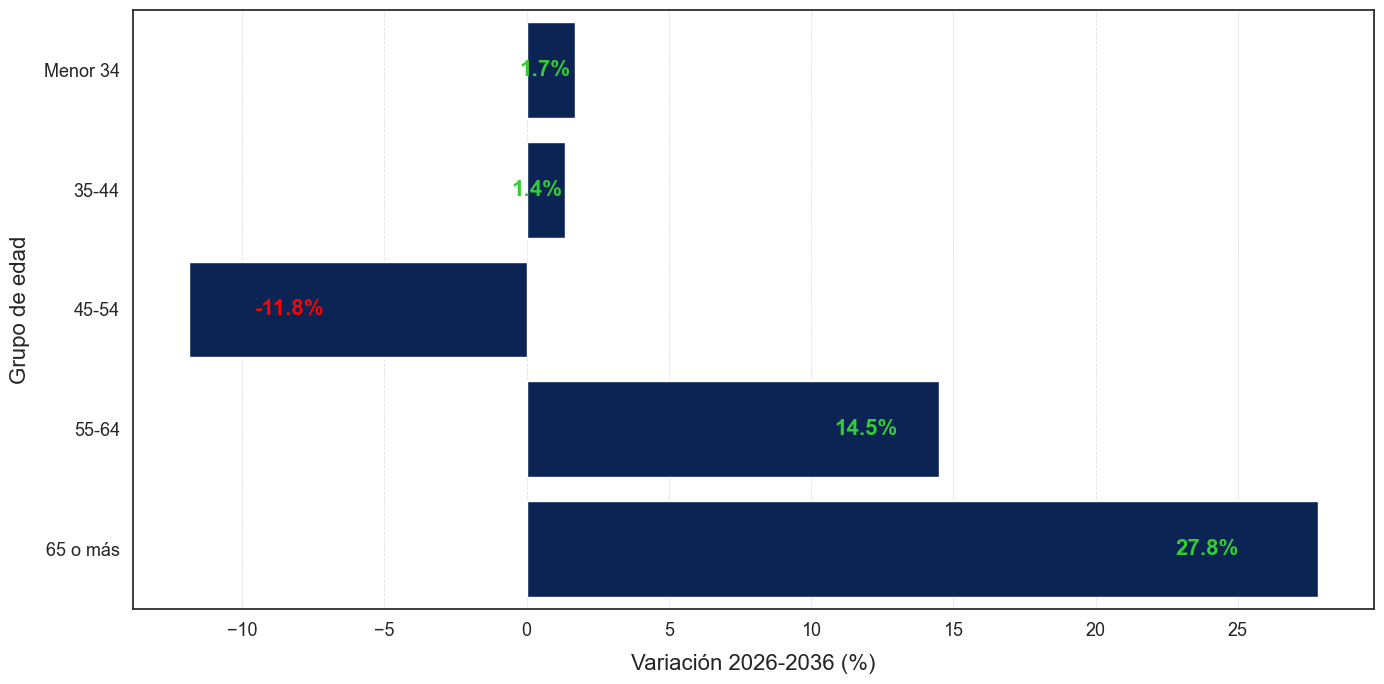

In [58]:
#Gráfico incrementos por edades:
plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.barplot(
    data=incremento,
    x="variacion",
    y="index",
    color="#002060",
    orient = "h"
)

#plt.title("Variación por grupo de edades 2026-2036",fontsize=22,fontweight="bold", pad = 10)

plt.xlabel("Variación 2026-2036 (%)", fontsize=16, labelpad=10)
plt.ylabel("Grupo de edad", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)


for y, v in enumerate(incremento["variacion"]):
    if v >= 0:
        # Positivos → texto un poco a la izquierda del extremo
        plt.text(
            v*0.9,
            y,
            f"{v:.1f}%",
            va="center",
            ha="right",
            fontsize=16,
            color="limegreen",
            fontweight="bold"
        )
    else:
        # Negativos → texto un poco a la derecha del extremo
        plt.text(
            v*0.6,
            y,
            f"{v:.1f}%",
            va="center",
            ha="right",
            fontsize=16,
            color="red",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [52]:
#Comparativa con distribución clientes empresa por edad:
anos_edad = proyeccion[proyeccion["Periodo"].isin([2026, 2036])][["Periodo","Menor 34", "35-44", "45-54", "55-64", "65 o más"]].copy()
anos_edad = anos_edad.set_index("Periodo")
comparativa = anos_edad.T.reset_index()

comparativa



Periodo,index,2026,2036
0,Menor 34,"17,551,549.65","17,848,984.49"
1,35-44,"6,593,651.44","6,683,842.10"
2,45-54,"8,133,931.72","7,170,402.39"
3,55-64,"7,168,322.58","8,206,681.74"
4,65 o más,"10,462,800.97","13,371,227.81"


In [53]:
#distribucion empresa
df_age = dist_edad_banco.reset_index()
df_age.columns = ["index", "Clientes 2026"]
df_age

,index,Clientes 2026
0,Menor 34,3908
1,35-44,3369
2,45-54,2204
3,55-64,1256
4,65 o más,425


In [18]:
#unir datos por edades:
df_edades = comparativa.merge(df_age, on="index", how="left")

cols = [2026, 2036, "Clientes 2026"]

df_edades[cols] = df_edades[cols].apply(lambda x: x / x.sum() * 100)
df_edades = df_edades.rename(columns={2026: "Población 2026",
                                      2036: "Población 2036"
})
df_edades

,index,Población 2026,Población 2036,Clientes 2026
0,Menor 34,35.17,33.50,35.01
1,35-44,13.21,12.54,30.18
2,45-54,16.30,13.46,19.75
3,55-64,14.36,15.40,11.25
4,65 o más,20.96,25.10,3.81


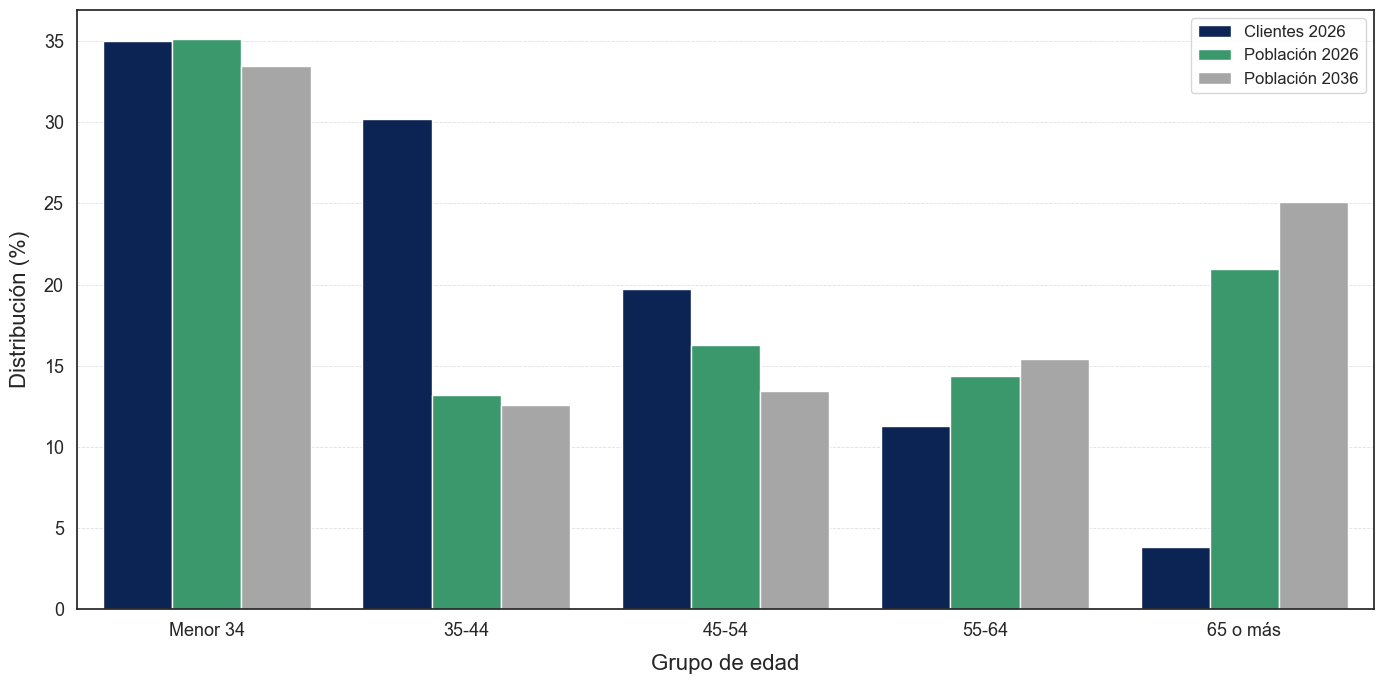

In [19]:
#Gráfico comparativa clientes por edades:
df_long = df_edades.melt(
    id_vars="index",
    value_vars=["Clientes 2026", "Población 2026","Población 2036"],
    var_name="tipo",
    value_name="porcentaje"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_long,
    x="index",
    y="porcentaje",
    hue="tipo",
    palette=["#002060", "#2BA86E", "#A6A6A6"]  # colores para 2026, 2036, clientes
)

#plt.title("Distribución por grupos de edad 2026-2036",fontsize=22,fontweight="bold",pad=10)

plt.xlabel("Grupo de edad", fontsize=16, labelpad=10)
plt.ylabel("Distribución (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

leg = plt.legend(title=None, fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()